# PlantVillage Leaf Disease Classification with Classical ML, ResNet18 and Grad‑CAM

# Imports and configuration 

In [ ]:
# %%
import os
from pathlib import Path
import random
import numpy as np
from PIL import Image
from torchvision import models, transforms

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

#  CONFIG 
DATA_DIR = Path(r"C:\Users\jeeva\Desktop\AI PROJECTS\archive\PlantVillage")

# All images will be resized/cropped to 224×224 
IMAGE_SIZE = (224, 224)


# To keep CPU training reasonable 
MAX_IMAGES_PER_CLASS = 300   
BATCH_SIZE = 32
NUM_EPOCHS_CNN = 30          
LEARNING_RATE = 1e-3

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)


Using device: cpu


# PATHS AND LABELS PREPARATION

In [ ]:
# %%
# Find class folders inside DATA_DIR
class_names = []
image_paths = []
labels = []


VALID_CLASSES = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy",
]

for cls in VALID_CLASSES:
    cls_dir = DATA_DIR / cls
    if not cls_dir.is_dir():
        print(f"WARNING: {cls_dir} not found, skipping")
        continue
    
    cls_images = sorted(
        [p for p in cls_dir.glob("*.jpg")] +
        [p for p in cls_dir.glob("*.jpeg")] +
        [p for p in cls_dir.glob("*.png")]
    )
      # Optionally limit images per class
    if MAX_IMAGES_PER_CLASS is not None:
        cls_images = cls_images[:MAX_IMAGES_PER_CLASS]
    
    image_paths.extend(cls_images)
    labels.extend([cls] * len(cls_images))
    class_names.append(cls)

print(f"Total images found: {len(image_paths)}")
print("Classes used:", sorted(set(labels)))


Total images found: 4352
Classes used: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


# Encode labels and create train/val/test splits 

In [85]:
# %%
# Encode text labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Stratified split: train, temp -> valid + test
paths_train, paths_temp, y_train, y_temp = train_test_split(
    image_paths, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

paths_val, paths_test, y_val, y_test = train_test_split(
    paths_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
print("Number of classes:", len(label_encoder.classes_))


Train: 3046, Val: 653, Test: 653
Number of classes: 15


# Feature extration 

In [86]:
# %%
def extract_color_features(img_path, image_size=IMAGE_SIZE, bins=32):
    """
    Load an image, resize, and extract colour histogram + mean/std features.
    Returns a 1D numpy array.
    """
    img = Image.open(img_path).convert("RGB")
    img = img.resize(image_size)
    arr = np.array(img)  # H x W x 3

    # Split channels
    r = arr[:, :, 0].ravel()
    g = arr[:, :, 1].ravel()
    b = arr[:, :, 2].ravel()

    hist_r, _ = np.histogram(r, bins=bins, range=(0, 255), density=True)
    hist_g, _ = np.histogram(g, bins=bins, range=(0, 255), density=True)
    hist_b, _ = np.histogram(b, bins=bins, range=(0, 255), density=True)

    # Mean and std for each channel
    stats = np.array([
        r.mean(), r.std(),
        g.mean(), g.std(),
        b.mean(), b.std()
    ])

    features = np.concatenate([hist_r, hist_g, hist_b, stats])
    return features

def build_feature_matrix(paths):
    X_list = []
    for p in tqdm(paths, desc="Extracting features"):
        X_list.append(extract_color_features(p))
    return np.vstack(X_list)

# Build train / val / test feature matrices
X_train = build_feature_matrix(paths_train)
X_val   = build_feature_matrix(paths_val)
X_test  = build_feature_matrix(paths_test)

print("Feature shape:", X_train.shape)


Extracting features: 100%|██████████| 653/653 [00:02<00:00, 217.98it/s]

Feature shape: (3046, 102)


# Classical models SVM, Random Forest and  k-NN 

In [ ]:
# %%
classical_models = {
    "SVM_linear": SVC(kernel="linear", probability=False, random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, max_depth=None, random_state=RANDOM_SEED
    ),
    "kNN": KNeighborsClassifier(n_neighbors=5)
}

results_classical = {}

for name, clf in classical_models.items():
    print(f"\n==== Training {name} ====")
     # StandardScaler + classifier; scaling helps SVM/kNN and is harmless for trees
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", clf)
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    print(f"{name} - Validation Accuracy: {acc:.4f}")
    print(classification_report(
        y_val, y_val_pred, target_names=label_encoder.classes_
    ))
    results_classical[name] = {
        "model": model,
        "val_accuracy": acc
    }

# Pick the best classical model based on val accuracy
best_name = max(results_classical, key=lambda k: results_classical[k]["val_accuracy"])
print(f"\nBest classical model: {best_name} "
      f"with val acc = {results_classical[best_name]['val_accuracy']:.4f}")
best_classical_model = results_classical[best_name]["model"]



==== Training SVM_linear ====
SVM_linear - Validation Accuracy: 0.7642
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.62      0.80      0.70        45
                     Pepper__bell___healthy       0.81      0.76      0.78        45
                      Potato___Early_blight       0.85      0.87      0.86        45
                       Potato___Late_blight       0.67      0.73      0.70        45
                           Potato___healthy       0.70      0.70      0.70        23
                      Tomato_Bacterial_spot       0.78      0.78      0.78        45
                        Tomato_Early_blight       0.70      0.67      0.68        45
                         Tomato_Late_blight       0.66      0.64      0.65        45
                           Tomato_Leaf_Mold       0.84      0.80      0.82        45
                  Tomato_Septoria_leaf_spot       0.65      0.62      0.64   

CLASSICAL ML COMPARISON 

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd
# Evaluate classical models on test set

test_scores = {}

for name, entry in results_classical.items():
    model = entry["model"]          # trained Pipeline(scaler + clf)
    y_pred = model.predict(X_test)  # predict on test features
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} – Test Accuracy: {acc:.4f}")
    test_scores[name] = acc

# Put in a small comparison table
compare_df = pd.DataFrame.from_dict(test_scores, orient="index",
                                    columns=["Test_Accuracy"])
compare_df = compare_df.sort_values("Test_Accuracy", ascending=False)

print("\n=== Classical models comparison (test set) ===")
print(compare_df)


SVM_linear – Test Accuracy: 0.7397
RandomForest – Test Accuracy: 0.7504
kNN – Test Accuracy: 0.7182

=== Classical models comparison (test set) ===
              Test_Accuracy
RandomForest       0.750383
SVM_linear         0.739663
kNN                0.718224


# Dataset and transforms for CNN (ResNet18) 

In [ ]:
from torchvision import transforms

class LeafDataset(Dataset):
    """
    Dataset that:
      - stores image paths + labels
      - applies a torchvision transform pipeline
    """
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = np.array(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)   # tensor (3, H, W)
        else:
            img = transforms.ToTensor()(img)

        return img, torch.tensor(label, dtype=torch.long)


# # Data augmentation for training to improve generalisation
train_transform = transforms.Compose([
    transforms.Resize(256),                    
    transforms.RandomResizedCrop(224,         
                                 scale=(0.8, 1.0),
                                 ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(                   # random colour changes
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# NO augmentation for val/test just resize + normalise
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Build datasets/loaders using correct transform
train_dataset = LeafDataset(paths_train, y_train, transform=train_transform)
val_dataset   = LeafDataset(paths_val,   y_val,   transform=eval_transform)
test_dataset  = LeafDataset(paths_test,  y_test,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

len(train_dataset), len(val_dataset), len(test_dataset)


(3046, 653, 653)

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_classes = len(label_encoder.classes_)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)


for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

cnn_model = resnet.to(DEVICE)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, cnn_model.parameters()), lr=1e-4)


# Training loop and learning curves

Epoch [1/30] Train Loss: 1.0511 Acc: 0.7328 | Val Loss: 0.3233 Acc: 0.9188
Epoch [2/30] Train Loss: 0.3358 Acc: 0.9130 | Val Loss: 0.2174 Acc: 0.9342


Epoch [3/30] Train Loss: 0.2032 Acc: 0.9501 | Val Loss: 0.2093 Acc: 0.9387
Epoch [4/30] Train Loss: 0.1656 Acc: 0.9576 | Val Loss: 0.1585 Acc: 0.9571
Epoch [5/30] Train Loss: 0.1274 Acc: 0.9675 | Val Loss: 0.1458 Acc: 0.9495
Epoch [6/30] Train Loss: 0.0957 Acc: 0.9796 | Val Loss: 0.1305 Acc: 0.9541
Epoch [7/30] Train Loss: 0.0825 Acc: 0.9793 | Val Loss: 0.1380 Acc: 0.9525
Epoch [8/30] Train Loss: 0.0686 Acc: 0.9836 | Val Loss: 0.1265 Acc: 0.9571
Epoch [9/30] Train Loss: 0.0857 Acc: 0.9750 | Val Loss: 0.1161 Acc: 0.9617
Epoch [10/30] Train Loss: 0.0739 Acc: 0.9787 | Val Loss: 0.1306 Acc: 0.9510
Epoch [11/30] Train Loss: 0.0524 Acc: 0.9872 | Val Loss: 0.1099 Acc: 0.9602
Epoch [12/30] Train Loss: 0.0570 Acc: 0.9836 | Val Loss: 0.0861 Acc: 0.9678
Epoch [13/30] Train Loss: 0.0449 Acc: 0.9879 | Val Loss: 0.0890 Acc: 0.9709
Epoch [14/30] Train Loss: 0.0413 Acc: 0.9902 | Val Loss: 0.1218 Acc: 0.9587
Epoch [15/30] Train Loss: 0.0474 Acc: 0.9869 | Val Loss: 0.1180 Acc: 0.9556
Epoch [16/30] Train

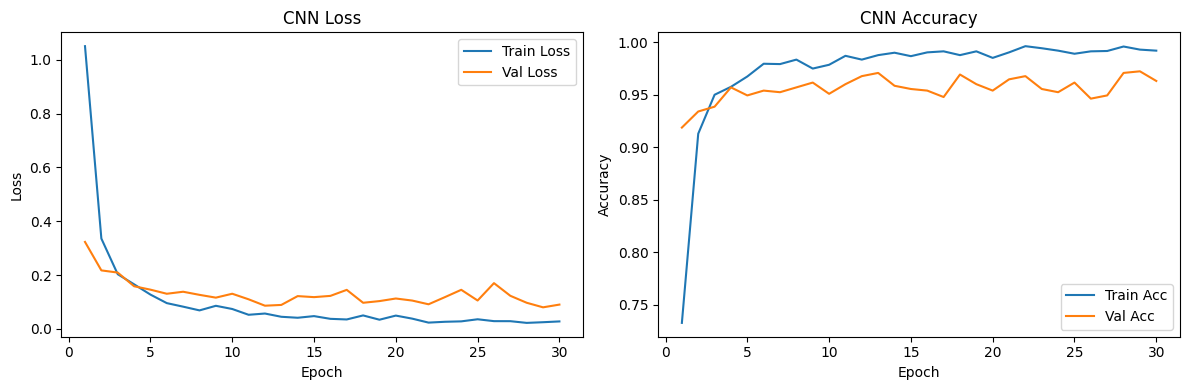

In [92]:
# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, preds = outputs.max(1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, running_correct / total

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, running_correct / total

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(1, NUM_EPOCHS_CNN + 1):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = eval_one_epoch(cnn_model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch}/{NUM_EPOCHS_CNN}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Plot learning curves
epochs = range(1, NUM_EPOCHS_CNN + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Accuracy")

plt.tight_layout()
plt.show()


 Extra fine-tuning on deeper layers

In [120]:
for name, param in resnet.named_parameters():
    if name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False


In [ ]:
# Smaller LR and weight decay for fine-tuning
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, cnn_model.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()


In [124]:
FT_EPOCHS = 5

for epoch in range(1, FT_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = eval_one_epoch(cnn_model, val_loader, criterion, DEVICE)

    print(f"[FT Epoch {epoch}/{FT_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


[FT Epoch 1/5] Train Loss: 0.0187 Acc: 0.9951 | Val Loss: 0.1216 Acc: 0.9587
[FT Epoch 2/5] Train Loss: 0.0185 Acc: 0.9970 | Val Loss: 0.1125 Acc: 0.9556
[FT Epoch 3/5] Train Loss: 0.0192 Acc: 0.9941 | Val Loss: 0.1142 Acc: 0.9602
[FT Epoch 4/5] Train Loss: 0.0189 Acc: 0.9947 | Val Loss: 0.0890 Acc: 0.9755
[FT Epoch 5/5] Train Loss: 0.0207 Acc: 0.9947 | Val Loss: 0.0802 Acc: 0.9709


CNN – Test Accuracy: 0.9495
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00        45
                     Pepper__bell___healthy       1.00      1.00      1.00        45
                      Potato___Early_blight       1.00      1.00      1.00        45
                       Potato___Late_blight       1.00      0.98      0.99        45
                           Potato___healthy       0.96      1.00      0.98        23
                      Tomato_Bacterial_spot       0.92      1.00      0.96        45
                        Tomato_Early_blight       0.97      0.71      0.82        45
                         Tomato_Late_blight       0.82      0.93      0.88        45
                           Tomato_Leaf_Mold       1.00      0.93      0.97        45
                  Tomato_Septoria_leaf_spot       0.86      0.93      0.89        45
Tomato_Spider_mites_Two_spotted_spid

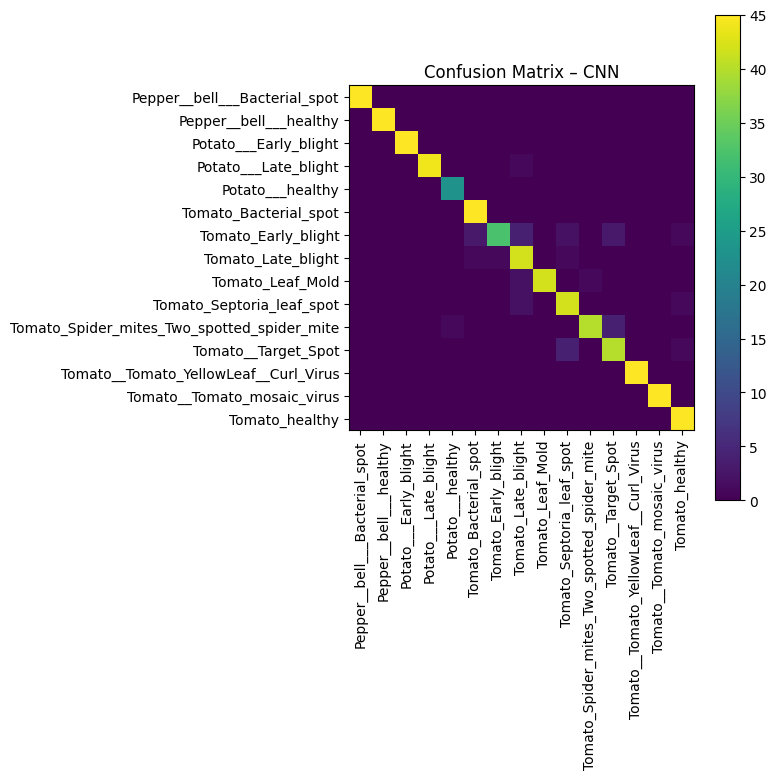

In [93]:
# %%
def get_all_preds(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_test_true, y_test_pred_cnn = get_all_preds(cnn_model, test_loader, DEVICE)

test_acc_cnn = accuracy_score(y_test_true, y_test_pred_cnn)
print(f"CNN – Test Accuracy: {test_acc_cnn:.4f}")
print(classification_report(
    y_test_true, y_test_pred_cnn, target_names=label_encoder.classes_
))

cm_cnn = confusion_matrix(y_test_true, y_test_pred_cnn)
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm_cnn, interpolation="nearest")
plt.title("Confusion Matrix – CNN")
plt.colorbar(im)
ax.set_xticks(range(len(label_encoder.classes_)))
ax.set_yticks(range(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=90)
ax.set_yticklabels(label_encoder.classes_)
plt.tight_layout()
plt.show()


# EVALUATION ON TEST SET 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

#  Classical ML on X_test 
y_pred_classical = best_classical_model.predict(X_test)
acc_classical = accuracy_score(y_test, y_pred_classical)
print(f"Classical ML – Test Accuracy: {acc_classical:.4f}")
print(classification_report(y_test, y_pred_classical,
                            target_names=label_encoder.classes_))

#  ResNet50 on test_loader 
def get_all_preds(model, loader, device):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_true_resnet, y_pred_resnet = get_all_preds(cnn_model, test_loader, DEVICE)
acc_resnet = accuracy_score(y_true_resnet, y_pred_resnet)
print(f"\nResNet50 – Test Accuracy: {acc_resnet:.4f}")
print(classification_report(y_true_resnet, y_pred_resnet,
                            target_names=label_encoder.classes_))

# ---------- Tiny summary ----------
print("\n=== Accuracy comparison ===")
print(f"Classical ML: {acc_classical:.4f}")
print(f"ResNet50    : {acc_resnet:.4f}")


Classical ML – Test Accuracy: 0.7504
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.67      0.73      0.70        45
                     Pepper__bell___healthy       0.72      0.51      0.60        45
                      Potato___Early_blight       0.75      0.93      0.83        45
                       Potato___Late_blight       0.61      0.80      0.69        45
                           Potato___healthy       0.68      0.65      0.67        23
                      Tomato_Bacterial_spot       0.75      0.80      0.77        45
                        Tomato_Early_blight       0.61      0.62      0.62        45
                         Tomato_Late_blight       0.85      0.64      0.73        45
                           Tomato_Leaf_Mold       0.78      0.87      0.82        45
                  Tomato_Septoria_leaf_spot       0.89      0.69      0.78        45
Tomato_Spider_mites_Two_spo

# GRAD-CAM Visualisation 

In [ ]:
import cv2
import torch
import numpy as np

def generate_gradcam(model, img_tensor, target_class=None, device=DEVICE):
    model.eval()
    img_batch = img_tensor.unsqueeze(0).to(device)

    activations = None
    gradients = None

    # Use the whole layer4 block as target
    target_layer = model.layer4

    def fwd_hook(module, inp, out):
        nonlocal activations
        activations = out          # shape: (1, C, H, W)

    def bwd_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]    # shape: (1, C, H, W)

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_backward_hook(bwd_hook)

    # Forward
    outputs = model(img_batch)
    if target_class is None:
        target_class = outputs.argmax(dim=1).item()
    score = outputs[0, target_class]

    # Backward
    model.zero_grad()
    score.backward()

    # Remove hooks
    h1.remove()
    h2.remove()

    # Activations & grads for this image
    A = activations[0]   # (C, H, W)
    G = gradients[0]     # (C, H, W)

    # Global-average-pool gradients 
    weights = G.mean(dim=(1, 2))   

    # Weighted sum of activations
    cam = torch.zeros(A.shape[1:], device=A.device)
    for c, w in enumerate(weights):
        cam += w * A[c]

    # ReLU and normalize
    cam = torch.relu(cam)
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    # detach before converting to numpy
    cam = cam.detach().cpu().numpy()
    cam = cv2.resize(cam, (224, 224))

    return cam, target_class


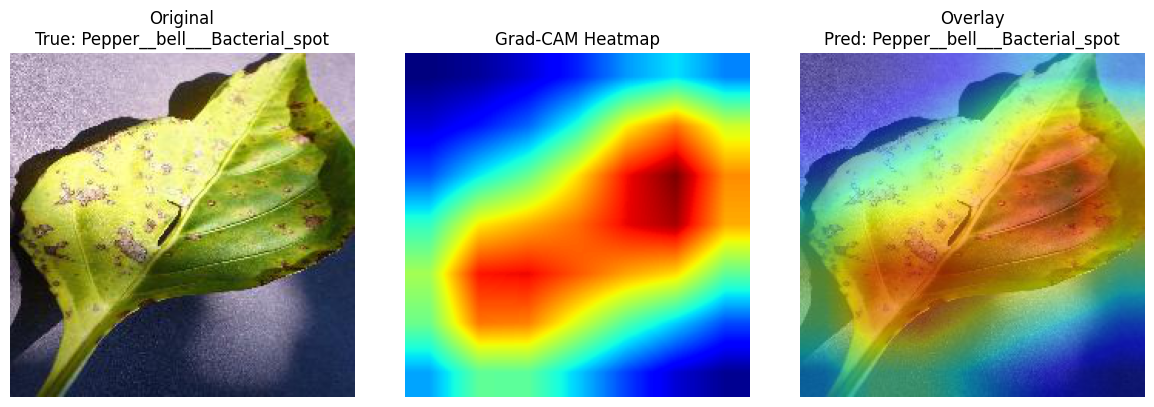

In [128]:
idx = 2

img_tensor, label = test_dataset[idx]
cam_resized, pred_class = generate_gradcam(cnn_model, img_tensor, device=DEVICE)

# reverse ImageNet normalisation
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * std) + mean
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {label_encoder.classes_[label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_resized, cmap="jet", alpha=0.5)
plt.title(f"Overlay\nPred: {label_encoder.classes_[pred_class]}")
plt.axis("off")

plt.tight_layout()
plt.show()


# SUMMARY 

In this task comparison of machine learning models with a deep CNN for crop-leaf disease classification on the PlantVillage dataset . All images were resized to 224×224 and normalised. For the classical baseline I extracted simple colour features which is  RGB histograms plus per-channel mean and standard deviation and trained SVM, k-NN and Random Forest classifiers. The best classical model was Random Forest, which reached about 0.75 test accuracy.

For deep learning I fine-tuned a pretrained ResNet-based CNN using data augmentation and a train/validation/test split of 3046/653/653 images. The CNN achieved around 0.95 test accuracy with macro-averaged precision, recall and F1 also close to 0.95 which shows a performance gain over the classical model expecially for cisually subtle disease 

Grad-CAM visualisations show that the CNN primarily concentrates on diseased leaf areas rather than the homogeneous background, emphasising patches of discolouration, texture changes, and clusters of spots.

After the initial training I unfreezed layer3, layer4 and fc, create a new optimizer with a slightly smaller learning rate and train for a few extra
epochs. Heatmaps however are relatiely smooth becasue the final feature map is low resolution and some classes have similar symtpoms . Issues due to lighting showed the heatmap classified the background as the disease which was later fixed


